This file is to essentially check the data within the new physics dataset, generated by Ahbay

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fizz_dataset = pd.read_csv("../data/processed/physics_modelled_2022_2025.csv")

First, check the number of races per year

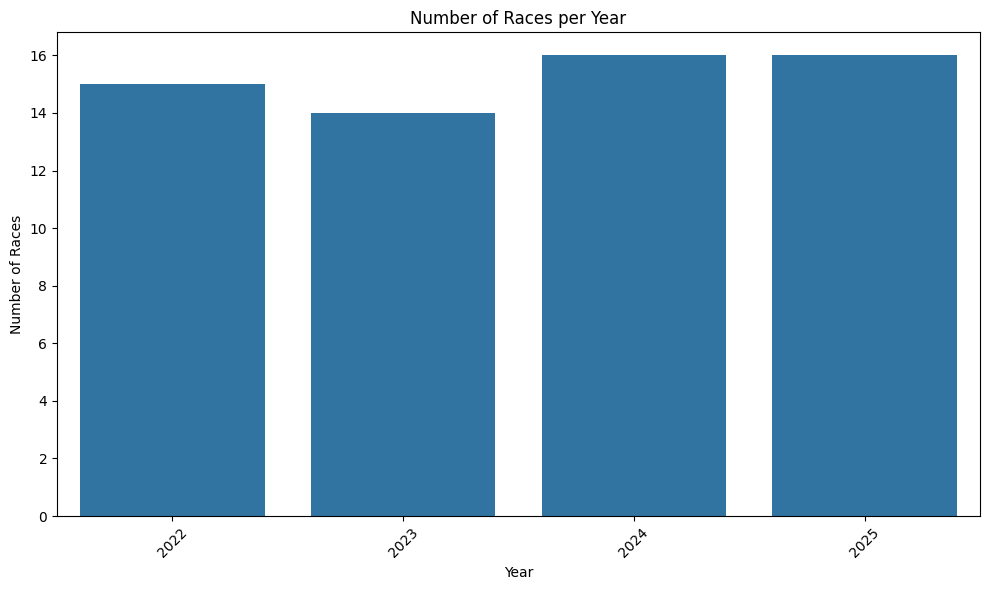

In [3]:
gr_races_year = fizz_dataset.groupby("Season")["RaceID"].nunique().reset_index(name="num_races")
plt.figure(figsize=(10, 6))
sns.barplot(x="Season", y="num_races", data=gr_races_year)
plt.title("Number of Races per Year")
plt.xlabel("Year")
plt.ylabel("Number of Races")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Then, check the number of drivers in each race (plot as a distribution of sorts)

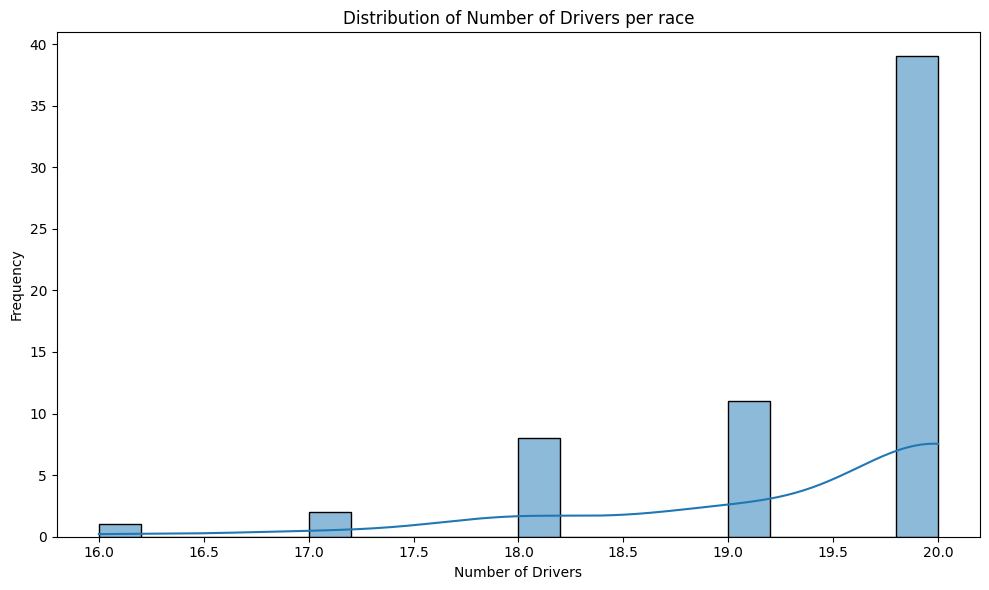

In [4]:
# group by races, get the number of unique drivers per race
gr_races = fizz_dataset.groupby("RaceID")["Driver"].nunique().reset_index(name="num_drivers")
# plot distribution of number of drivers
plt.figure(figsize=(10, 6))
sns.histplot(gr_races["num_drivers"], bins=20, kde=True)
plt.title("Distribution of Number of Drivers per race")
plt.xlabel("Number of Drivers")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

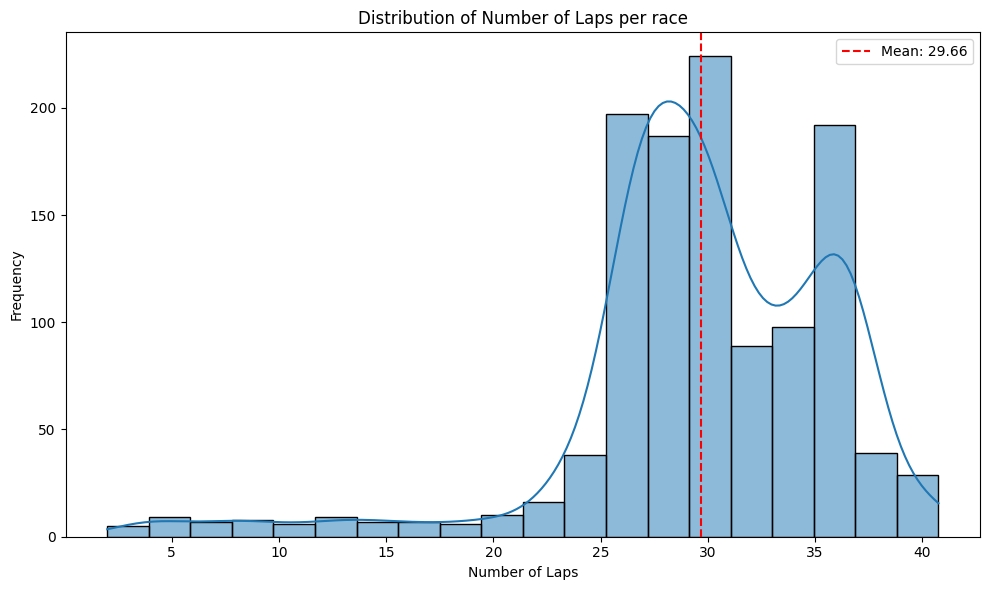

In [5]:
# next plot the distribution of the mean number of laps per driver race
gr_laps = fizz_dataset.groupby(["RaceID", "Driver"])["LapNumber"].mean().reset_index(name="LapNumber")
# plot the mean number of laps per driver as a scalar value

gr_laps_mean =gr_laps["LapNumber"].mean()
plt.figure(figsize=(10, 6))
sns.histplot(gr_laps["LapNumber"], bins=20, kde=True)
plt.axvline(gr_laps_mean, color='red', linestyle='--', label=f'Mean: {gr_laps_mean:.2f}')
plt.legend()
plt.title("Distribution of Number of Laps per race")
plt.xlabel("Number of Laps")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Now to check the physics attributes

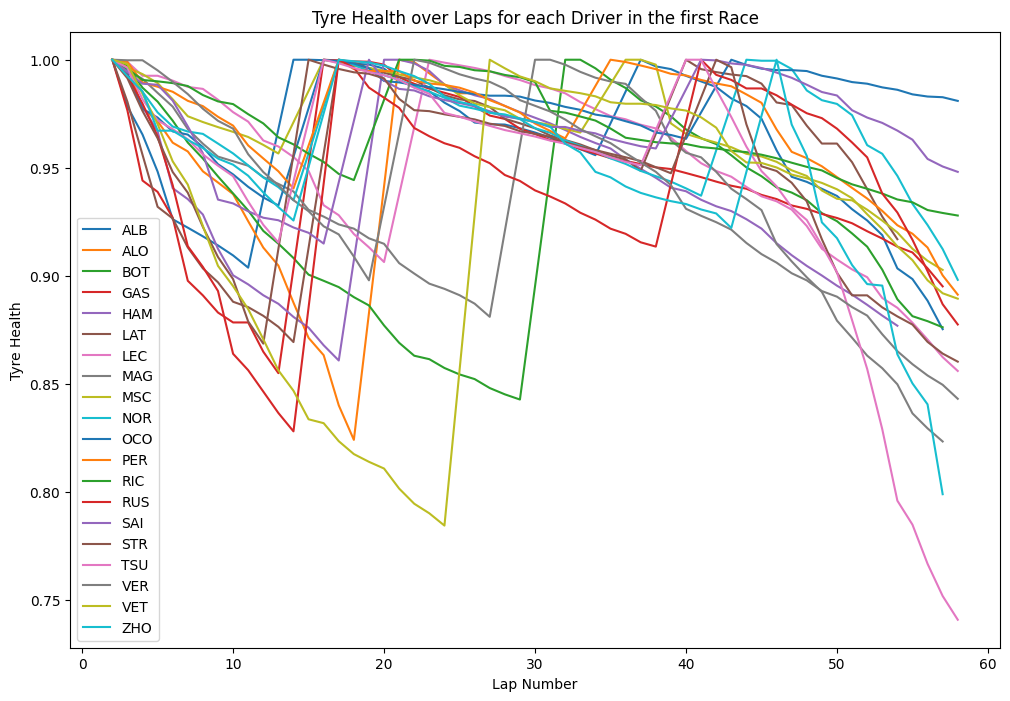

In [6]:
# for the first race in the dataset, plot the tyre health over the laps for each driver
first_race_df = fizz_dataset[fizz_dataset["RaceID"] == fizz_dataset["RaceID"].unique()[0]]
driver_groups = first_race_df.groupby("Driver")
plt.figure(figsize=(12, 8))
for driver, group in driver_groups:
    plt.plot(group["LapNumber"], group["TyreHealth"], label=driver)
plt.title("Tyre Health over Laps for each Driver in the first Race")
plt.xlabel("Lap Number")
plt.ylabel("Tyre Health")
plt.legend()
plt.show()

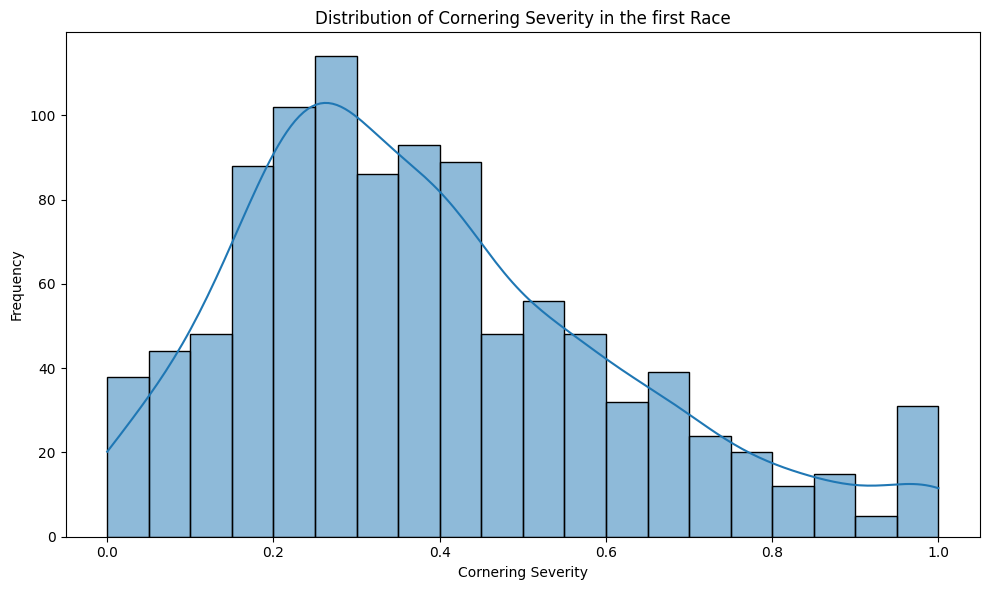

In [7]:
# now plot the distribution of cornering severiy for the same dataset
plt.figure(figsize=(10, 6))
sns.histplot(first_race_df["CorneringSeverity"], bins=20, kde=True)
plt.title("Distribution of Cornering Severity in the first Race")
plt.xlabel("Cornering Severity")
plt.ylabel("Frequency")
plt.tight_layout()

In [8]:
# now to test the correlation between tyre health and various statistics.
# to do this, we will group the dataset by race and driver, compute the difference in tyre health for each driver.
working_df = fizz_dataset.copy()
working_df.groupby(["RaceID", "Driver"])["TyreHealth"]
# sort by lapNumber just to be sure
working_df = working_df.sort_values(by=["RaceID", "Driver", "LapNumber"])
working_df["TyreHealthDiff"] = working_df.groupby(["RaceID", "Driver"])["TyreHealth"].diff()
# remove all cases where diff was positive; that is where a tyre change took place
working_df = working_df.fillna(0) # ie no change in tyre health for the first lap
working_df = working_df[working_df["TyreHealthDiff"] <= 0]

working_df["TyreHealthDiff"].head(10)

0    0.000000
1   -0.021650
2   -0.012986
3   -0.017157
4   -0.022093
5   -0.003891
6   -0.004020
7   -0.004192
8   -0.004636
9   -0.005666
Name: TyreHealthDiff, dtype: float64

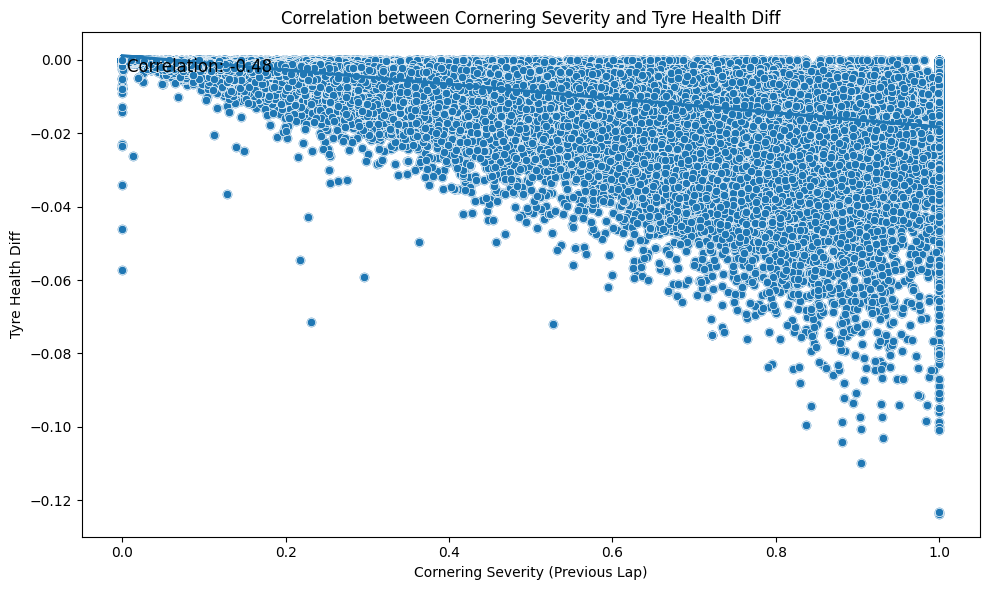

In [9]:
# plot the correlation between tyre health diff and cornering severity from the previous lap.
working_df["CorneringSeverityPrev"] = working_df.groupby(["RaceID", "Driver"])["CorneringSeverity"].shift(1)
plt.figure(figsize=(10, 6))
# add a regression line to the scatter plot
sns.regplot(x="CorneringSeverityPrev", y="TyreHealthDiff", data=working_df)
# add a correlation coefficient to the plot
corr = working_df[["CorneringSeverityPrev", "TyreHealthDiff"]].corr().iloc[0, 1]
plt.text(0.05, 0.95, f'Correlation: {corr:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
sns.scatterplot(x="CorneringSeverityPrev", y="TyreHealthDiff", data=working_df)
plt.title("Correlation between Cornering Severity and Tyre Health Diff")
plt.xlabel("Cornering Severity (Previous Lap)")
plt.ylabel("Tyre Health Diff")
plt.tight_layout()
plt.show()

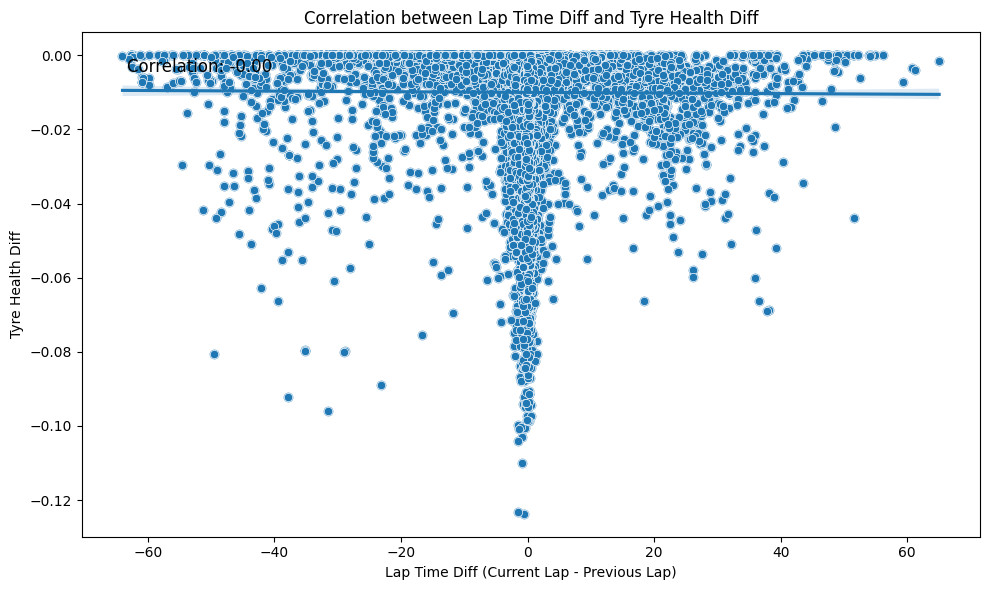

In [10]:
# plot the correlation between tyre health and the increase in lap time wrt the previous lap
working_df["LapTimeDiff"] = working_df.groupby(["RaceID", "Driver"])["LapTime_s"].diff()

plt.figure(figsize=(10, 6))
# add a regression line to the scatter plot
sns.regplot(x="LapTimeDiff", y="TyreHealthDiff", data=working_df)
# add a correlation coefficient to the plot
corr = working_df[["LapTimeDiff", "TyreHealthDiff"]].corr().iloc[0, 1]
plt.text(0.05, 0.95, f'Correlation: {corr:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
sns.scatterplot(x="LapTimeDiff", y="TyreHealthDiff", data=working_df)
plt.title("Correlation between Lap Time Diff and Tyre Health Diff")
plt.xlabel("Lap Time Diff (Current Lap - Previous Lap)")
plt.ylabel("Tyre Health Diff")
plt.tight_layout()
plt.show()

Above plot shows that there is too much noise to see for sure the effect of tyre health change on lap time.

In [11]:
# see if psi(T) has any activation in the dataset
print(fizz_dataset["Psi_T"].describe())
print(fizz_dataset["Psi_T"].value_counts())
print(f"{fizz_dataset['TyreTemp_C'].describe()=}")

count    61605.000000
mean         1.028920
std          0.087757
min          1.000000
25%          1.000000
50%          1.000000
75%          1.002271
max          2.157402
Name: Psi_T, dtype: float64
Psi_T
1.000000    44224
1.151560        1
1.030414        1
1.026371        1
1.010766        1
            ...  
1.033229        1
1.033781        1
1.014193        1
1.025120        1
1.108519        1
Name: count, Length: 17382, dtype: int64
fizz_dataset['TyreTemp_C'].describe()=count    61605.000000
mean        73.599841
std         23.078181
min         25.032074
25%         54.510501
50%         74.702280
75%         92.131081
max        138.112417
Name: TyreTemp_C, dtype: float64


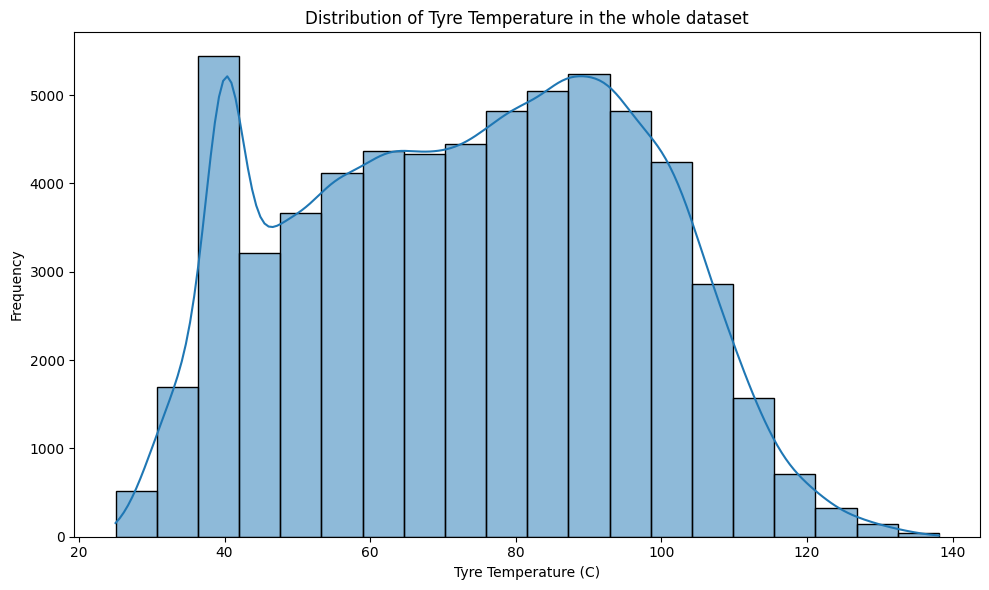

In [12]:
# plot the distribution of tyre temperature for the whole dataset
plt.figure(figsize=(10, 6))
sns.histplot(fizz_dataset["TyreTemp_C"], bins=20, kde=True)
plt.title("Distribution of Tyre Temperature in the whole dataset")
plt.xlabel("Tyre Temperature (C)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [13]:
# work out steady state tyre temperature for each stint, and plot the distribution of that
# T* is given by T_air +aF_zv_s / b where a and b are constants, F_z is the vertical load, v_s is the sliding velocity

A_TEMP = 1e-5       # calibrated heating coefficient
B_COOL = 0.005      # calibrated cooling coefficient
fizz_dataset["T_star"] = fizz_dataset["T_env_C"] + A_TEMP * fizz_dataset["Fz_N"] * fizz_dataset["SlidingProxy"] / B_COOL
plt.figure(figsize=(10, 6))
sns.histplot(fizz_dataset["T_star"], bins=20, kde=True)
plt.title("Distribution of Steady State Tyre Temperature (T*) in the whole dataset")
plt.xlabel("Steady State Tyre Temperature (C)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

KeyError: 'T_env_C'

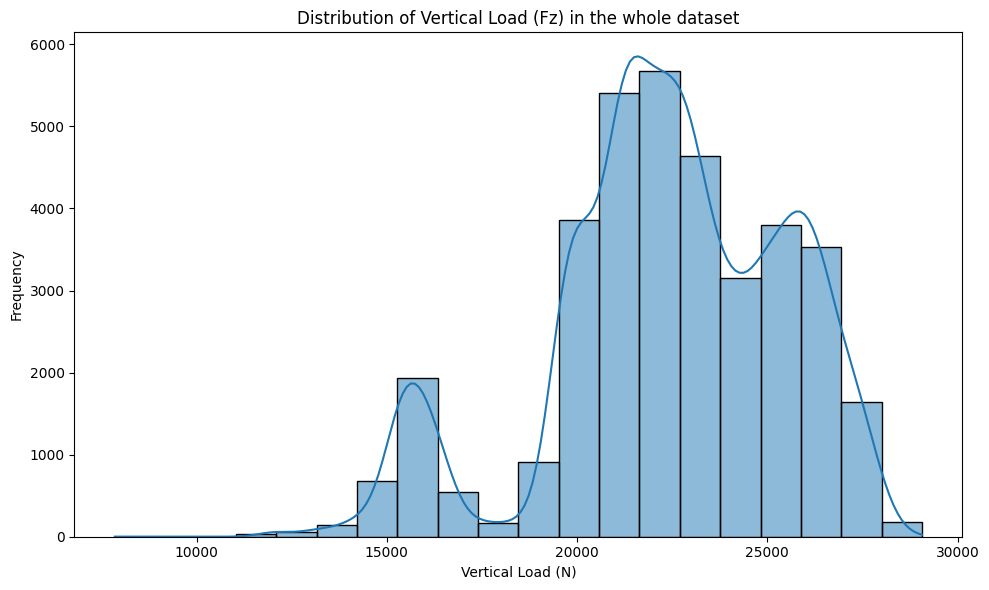

In [ ]:
# plot distribution of F_z
plt.figure(figsize=(10, 6))
sns.histplot(fizz_dataset["Fz_N"], bins=20, kde=True)
plt.title("Distribution of Vertical Load (Fz) in the whole dataset")
plt.xlabel("Vertical Load (N)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

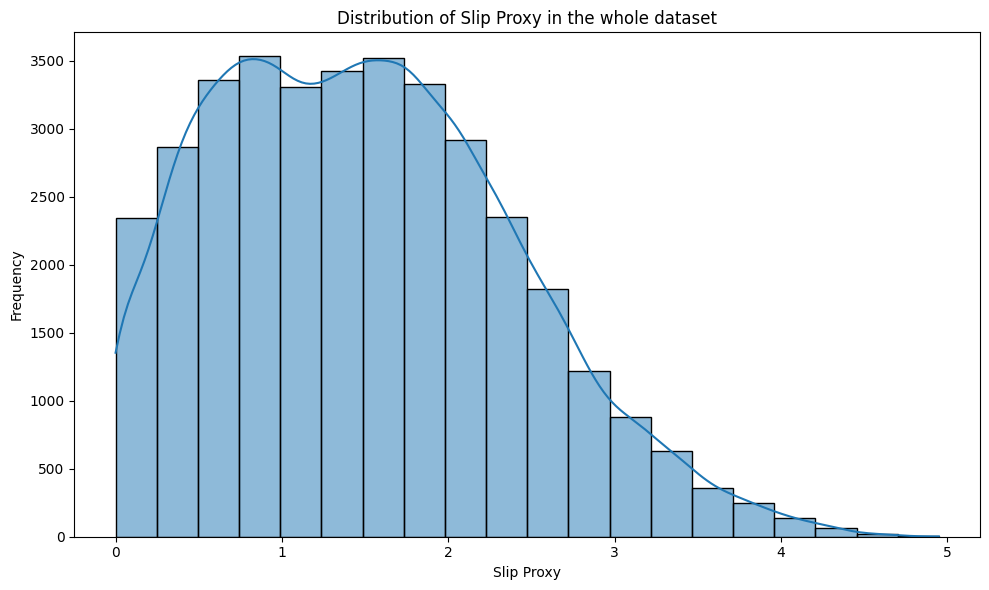

In [ ]:
# plot histogram of slip proxy
plt.figure(figsize=(10, 6))
sns.histplot(fizz_dataset["SlidingProxy"], bins=20, kde=True)
plt.title("Distribution of Slip Proxy in the whole dataset")
plt.xlabel("Slip Proxy")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

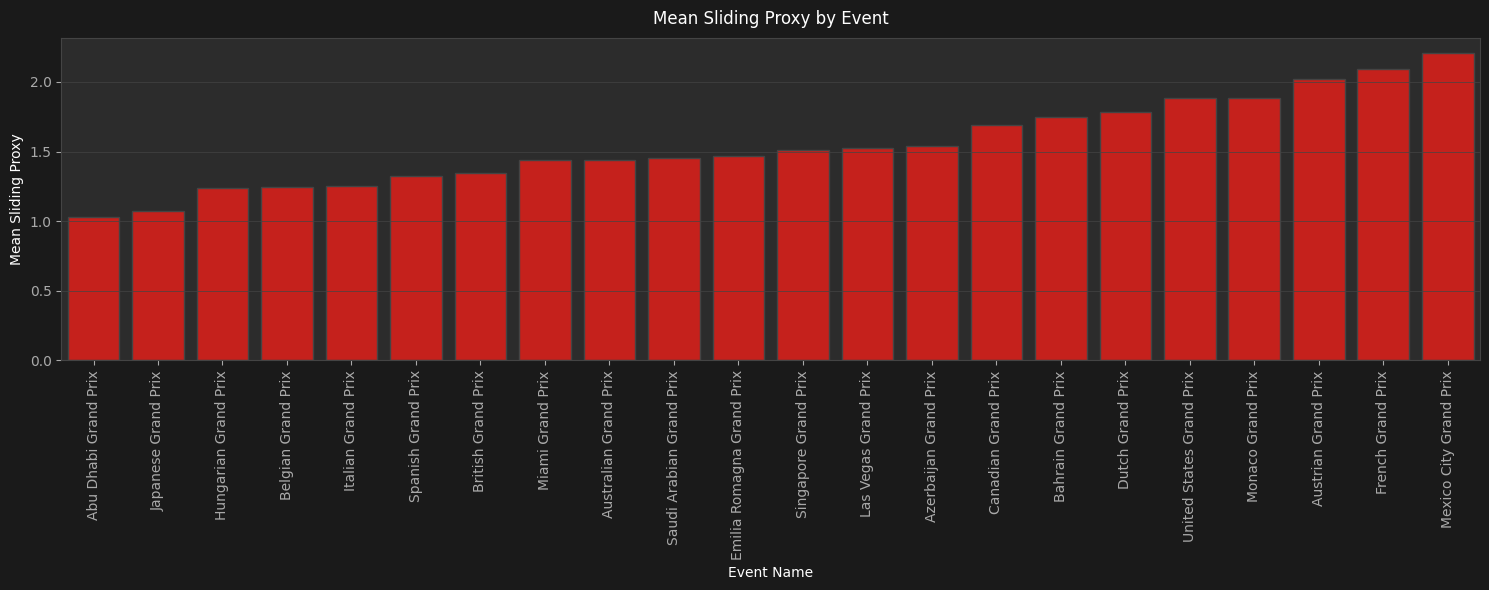

In [20]:
COLORS = {
    'background': '#1A1A1A',
    'axes':       '#2C2C2C',
    'grid':       '#444444',
    'text':       '#FFFFFF',
    'text_muted': '#AAAAAA',
    'soft':       '#E10600',
    'medium':     '#4A90D9',
    'hard':       '#00B4A6',
    'secondary':  '#AAAAAA',
}

plot_df = (
    fizz_dataset.groupby('EventName', as_index=False)['SlidingProxy']
    .mean()
    .sort_values('SlidingProxy')
)

fig_w = 15
fig_h = 6
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
fig.patch.set_facecolor(COLORS['background'])
ax.set_facecolor(COLORS['axes'])
ax.tick_params(colors=COLORS['text_muted'])
ax.xaxis.label.set_color(COLORS['text'])
ax.yaxis.label.set_color(COLORS['text'])
ax.title.set_color(COLORS['text'])
ax.grid(color=COLORS['grid'], linewidth=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor(COLORS['grid'])

sns.barplot(
    data=plot_df,
    x='EventName',
    y='SlidingProxy',
    color=COLORS['soft'],
    ax=ax,
    edgecolor=COLORS['grid']
 )

ax.set_title('Mean Sliding Proxy by Event', pad=10)
ax.set_xlabel('Event Name')
ax.set_ylabel('Mean Sliding Proxy')
ax.tick_params(axis='x', rotation=90, colors=COLORS['text_muted'])

plt.tight_layout()
plt.savefig('../figures/mean_sliding_proxy_by_event.pdf')

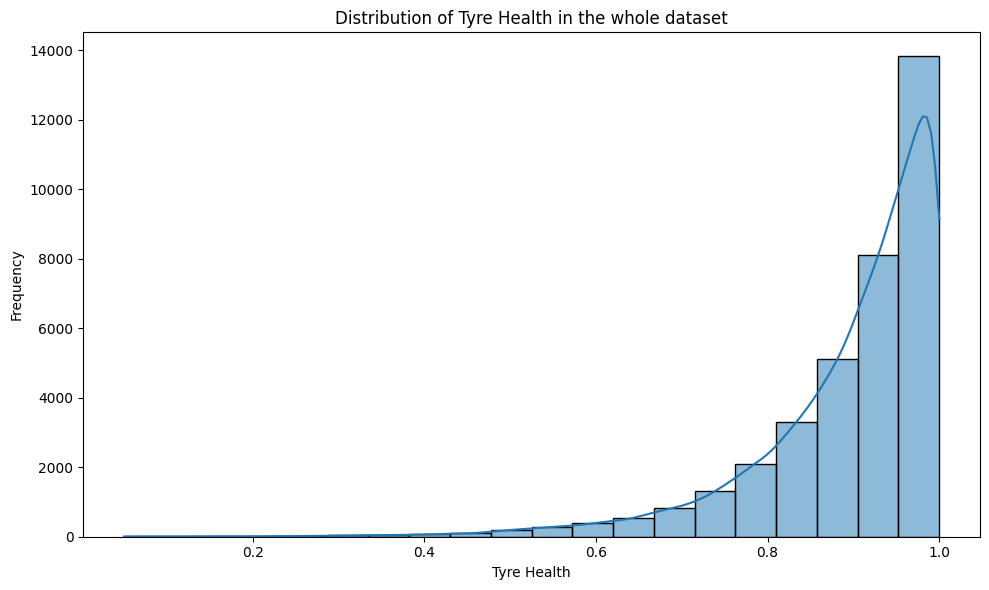

In [ ]:
# distributton of tyre health in dataset.
plt.figure(figsize=(10, 6))
sns.histplot(fizz_dataset["TyreHealth"], bins=20, kde=True)
plt.title("Distribution of Tyre Health in the whole dataset")
plt.xlabel("Tyre Health")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

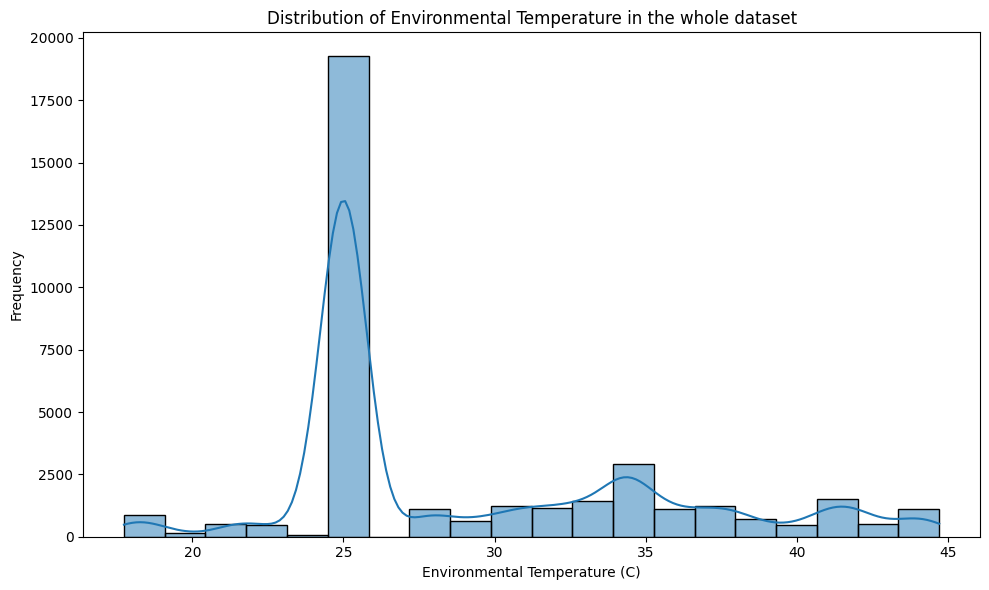

In [ ]:
# plot the distributions of enviroment temperature
plt.figure(figsize=(10, 6))
sns.histplot(fizz_dataset["T_env_C"], bins=20, kde=True)
plt.title("Distribution of Environmental Temperature in the whole dataset")
plt.xlabel("Environmental Temperature (C)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()